# Fase 1 - Análisis Exploratorio de Datos (EDA)

El objetivo de esta fase es explorar y entender los datos disponibles. Describiremos las variables con graficos y estadísticas descriptivas, para identificar patrones, tendencias y posibles problemas en los datos.

In [1]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import sweetviz as sv
from autoviz.AutoViz_Class import AutoViz_Class

# Customizaciones
sns.set_style('darkgrid')
pd.set_option('display.max_columns', None)

Imported v0.1.905. Please call AutoViz in this sequence:
    AV = AutoViz_Class()
    %matplotlib inline
    dfte = AV.AutoViz(filename, sep=',', depVar='', dfte=None, header=0, verbose=1, lowess=False,
               chart_format='svg',max_rows_analyzed=150000,max_cols_analyzed=30, save_plot_dir=None)


### Antes de iniciar la exploración de los datos, vamos a verificar si hay datos duplicados o nulos.

In [2]:
# Cargar los datos en un DataFrame de pandas

filename = 'data/diabetes_binary_5050split_health_indicators_BRFSS2015.csv'
df = pd.read_csv(filename)

print(f"Datos nulos: {df.isnull().sum()}")
print(f"Numero de filas duplicadas: {df.duplicated().sum()}")


Datos nulos: Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64
Numero de filas duplicadas: 1635


### Si necesario eliminar los datos duplicados o gestionar los datos perdidos

In [3]:
# Eliminar filas duplicadas
df.drop_duplicates(inplace=True)

# Verificar nuevamente los datos duplicados
print(f"Numero de filas duplicadas: {df.duplicated().sum()}")

Numero de filas duplicadas: 0


### Las variables, descriciones y valores.

| Variable               | Descripción                                                                            | Valores posibles                                                                                                                                                                                                                                                                                            |                            |
| ---------------------- | -------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | -------------------------- |
| `Diabetes_binary`      | Indica si el encuestado tiene diabetes o prediabetes.                                  | 0 = No tiene diabetes, 1 = Tiene prediabetes o diabetes                                                                                                                                                                                                                                                     |                            |
| `HighBP`               | Indica si el encuestado tiene hipertensión.                                            | 0 = No tiene hipertensión, 1 = Tiene hipertensión                                                                                                                                                                                                                                                           |                            |
| `HighChol`             | Indica si el encuestado tiene colesterol alto.                                         | 0 = No tiene colesterol alto, 1 = Tiene colesterol alto                                                                                                                                                                                                                                                     |                            |
| `CholCheck`            | Indica si el encuestado ha tenido un chequeo de colesterol en los últimos 5 años.      | 0 = No, 1 = Sí                                                                                                                                                                                                                                                                                              |                            |
| `BMI`                  | Índice de masa corporal del encuestado.                                                | Valor numérico                                                                                                                                                                                                                                                                                              |                            |
| `Smoker`               | Indica si el encuestado es fumador.                                                    | 0 = No fuma, 1 = Fuma                                                                                                                                                                                                                                                                                       |                            |
| `Stroke`               | Indica si el encuestado ha tenido un derrame cerebral.                                 | 0 = No ha tenido, 1 = Ha tenido                                                                                                                                                                                                                                                                             |                            |
| `HeartDiseaseorAttack` | Indica si el encuestado ha tenido una enfermedad cardíaca o ataque al corazón.         | 0 = No ha tenido, 1 = Ha tenido                                                                                                                                                                                                                                                                             |                            |
| `PhysActivity`         | Indica si el encuestado realiza actividad física en su tiempo libre.                   | 0 = No, 1 = Sí                                                                                                                                                                                                                                                                                              |                            |
| `Fruits`               | Indica si el encuestado consume frutas al menos una vez al día.                        | 0 = No, 1 = Sí                                                                                                                                                                                                                                                                                              |                            |
| `Veggies`              | Indica si el encuestado consume verduras al menos una vez al día.                      | 0 = No, 1 = Sí                                                                                                                                                                                                                                                                                              |                            |
| `HvyAlcoholConsump`    | Indica si el encuestado consume alcohol en exceso.                                     | 0 = No, 1 = Sí                                                                                                                                                                                                                                                                                              |                            |
| `AnyHealthcare`        | Indica si el encuestado tiene acceso a atención médica.                                | 0 = No, 1 = Sí                                                                                                                                                                                                                                                                                              |                            |
| `NoDocbcCost`          | Indica si el encuestado no ha visitado al médico debido a costos.                      | 0 = No, 1 = Sí                                                                                                                                                                                                                                                                                              |                            |
| `GenHlth`              | Autoevaluación del estado de salud general del encuestado.                             | 1 = Excelente, 2 = Muy buena, 3 = Buena, 4 = Regular, 5 = Mala                                                                                                                                                                                                                                              |                            |
| `MentHlth`             | Número de días en los últimos 30 días que la salud mental del encuestado no fue buena. | Valor numérico (días)                                                                                                                                                                                                                                                                                       |                            |
| `PhysHlth`             | Número de días en los últimos 30 días que la salud física del encuestado no fue buena. | Valor numérico (días)                                                                                                                                                                                                                                                                                       |                            |
| `DiffWalk`             | Indica si el encuestado tiene dificultad para caminar.                                 | 0 = No, 1 = Sí                                                                                                                                                                                                                                                                                              |                            |
| `Sex`                  | Sexo del encuestado.                                                                   | 0 = Hombre, 1 = Mujer                                                                                                                                                                                                                                                                                       |                            |
| `Age`                  | Rango de edad del encuestado.                                                          | 1 = 18-24, 2 = 25-29, 3 = 30-34, 4 = 35-39, 5 = 40-44, 6 = 45-49, 7 = 50-54, 8 = 55-59, 9 = 60-64, 10 = 65-69, 11 = 70-74, 12 = 75-79, 13 = 80+                                                                                                                                                             |                            |
| `Education`            | Nivel educativo alcanzado por el encuestado.                                           | 1 = Menos de primaria, 2 = Primaria, 3 = Secundaria, 4 = Preparatoria, 5 = Universidad o más                                                                                                                                                                                                                |                            |
| `Income`               | Nivel de ingresos anuales del encuestado.                                              | 1 = Menos de \$10,000, 2 = \$10,000–\$14,999, 3 = \$15,000–\$19,999, 4 = \$20,000–\$24,999, 5 = \$25,000–\$29,999, 6 = \$30,000–\$34,999, 7 = \$35,000–\$39,999, 8 = \$40,000–\$44,999, 9 = \$45,000–\$49,999, 10 = \$50,000–\$59,999, 11 = \$60,000–\$74,999, 12 = \$75,000–\$99,999, 13 = \$100,000 o más |                            |


### Una primera vista del conjunto de datos

In [4]:
# Mostrar la cantidad de filas y columnas
print(f"Dimensiones del DataFrame: {df.shape}")

# Mostrar las primeras filas del DataFrame
print(df.head())

Dimensiones del DataFrame: (69057, 22)
   Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0        0.0          1.0      0.0       1.0     26.0    0.0     0.0    
1        0.0          1.0      1.0       1.0     26.0    1.0     1.0    
2        0.0          0.0      0.0       1.0     26.0    0.0     0.0    
3        0.0          1.0      1.0       1.0     28.0    1.0     0.0    
4        0.0          0.0      0.0       1.0     29.0    1.0     0.0    

   HeartDiseaseorAttack  PhysActivity  Fruits  Veggies  HvyAlcoholConsump  \
0           0.0               1.0        0.0     1.0           0.0          
1           0.0               0.0        1.0     0.0           0.0          
2           0.0               1.0        1.0     1.0           0.0          
3           0.0               1.0        1.0     1.0           0.0          
4           0.0               1.0        1.0     1.0           0.0          

   AnyHealthcare  NoDocbcCost  GenHlth  MentHlth  PhysHlth 

### Generar algunos graficos y informes con sweeviz y autoviz

In [5]:
# Un informe de Sweetviz para un análisis exploratorio detallado
report = sv.analyze(df)
report.show_html('./reports/eda_report.html')

                                             |          | [  0%]   00:00 -> (? left)

Report ./reports/eda_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


Shape of your Data Set loaded: (69057, 22)
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#######################################################################################
Classifying variables in data set...
    Number of Numeric Columns =  7
    Number of Integer-Categorical Columns =  0
    Number of String-Categorical Columns =  0
    Number of Factor-Categorical Columns =  0
    Number of String-Boolean Columns =  0
    Number of Numeric-Boolean Columns =  14
    Number of Discrete String Columns =  0
    Number of NLP String Columns =  0
    Number of Date Time Columns =  0
    Number of ID Columns =  0
    Number of Columns to Delete =  0
    21 Predictors classified...
        No variables removed since no ID or low-information variables found in data set

################ Binary_Classification problem #####################
To fix these data qua

,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
HighBP,float64,0.000000,0,0.000000,1.000000,No issue
HighChol,float64,0.000000,0,0.000000,1.000000,No issue
CholCheck,float64,0.000000,0,0.000000,1.000000,No issue
BMI,float64,0.000000,NA,12.000000,98.000000,Column has 2181 outliers greater than upper bound (45.00) or lower than lower bound(13.00). Cap them or remove them.
Smoker,float64,0.000000,0,0.000000,1.000000,No issue
Stroke,float64,0.000000,0,0.000000,1.000000,No issue
HeartDiseaseorAttack,float64,0.000000,0,0.000000,1.000000,No issue
PhysActivity,float64,0.000000,0,0.000000,1.000000,No issue
Fruits,float64,0.000000,0,0.000000,1.000000,No issue
Veggies,float64,0.000000,0,0.000000,1.000000,No issue


Total Number of Scatter Plots = 28
No categorical or numeric vars in data set. Hence no bar charts.
All Plots done
Time to run AutoViz = 17 seconds 

 ###################### AUTO VISUALIZATION Completed ########################
Shape of your Data Set loaded: (70692, 22)
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#######################################################################################
Classifying variables in data set...
    Number of Numeric Columns =  7
    Number of Integer-Categorical Columns =  0
    Number of String-Categorical Columns =  0
    Number of Factor-Categorical Columns =  0
    Number of String-Boolean Columns =  0
    Number of Numeric-Boolean Columns =  15
    Number of Discrete String Columns =  0
    Number of NLP String Columns =  0
    Number of Date Time Columns =  0
    Number of ID Columns =  0
    Number of Column

,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
Diabetes_binary,float64,0.000000,0,0.000000,1.000000,No issue
HighBP,float64,0.000000,0,0.000000,1.000000,No issue
HighChol,float64,0.000000,0,0.000000,1.000000,No issue
CholCheck,float64,0.000000,0,0.000000,1.000000,No issue
BMI,float64,0.000000,NA,12.000000,98.000000,Column has 2181 outliers greater than upper bound (45.00) or lower than lower bound(13.00). Cap them or remove them.
Smoker,float64,0.000000,0,0.000000,1.000000,No issue
Stroke,float64,0.000000,0,0.000000,1.000000,No issue
HeartDiseaseorAttack,float64,0.000000,0,0.000000,1.000000,No issue
PhysActivity,float64,0.000000,0,0.000000,1.000000,No issue
Fruits,float64,0.000000,0,0.000000,1.000000,No issue


Number of All Scatter Plots = 28


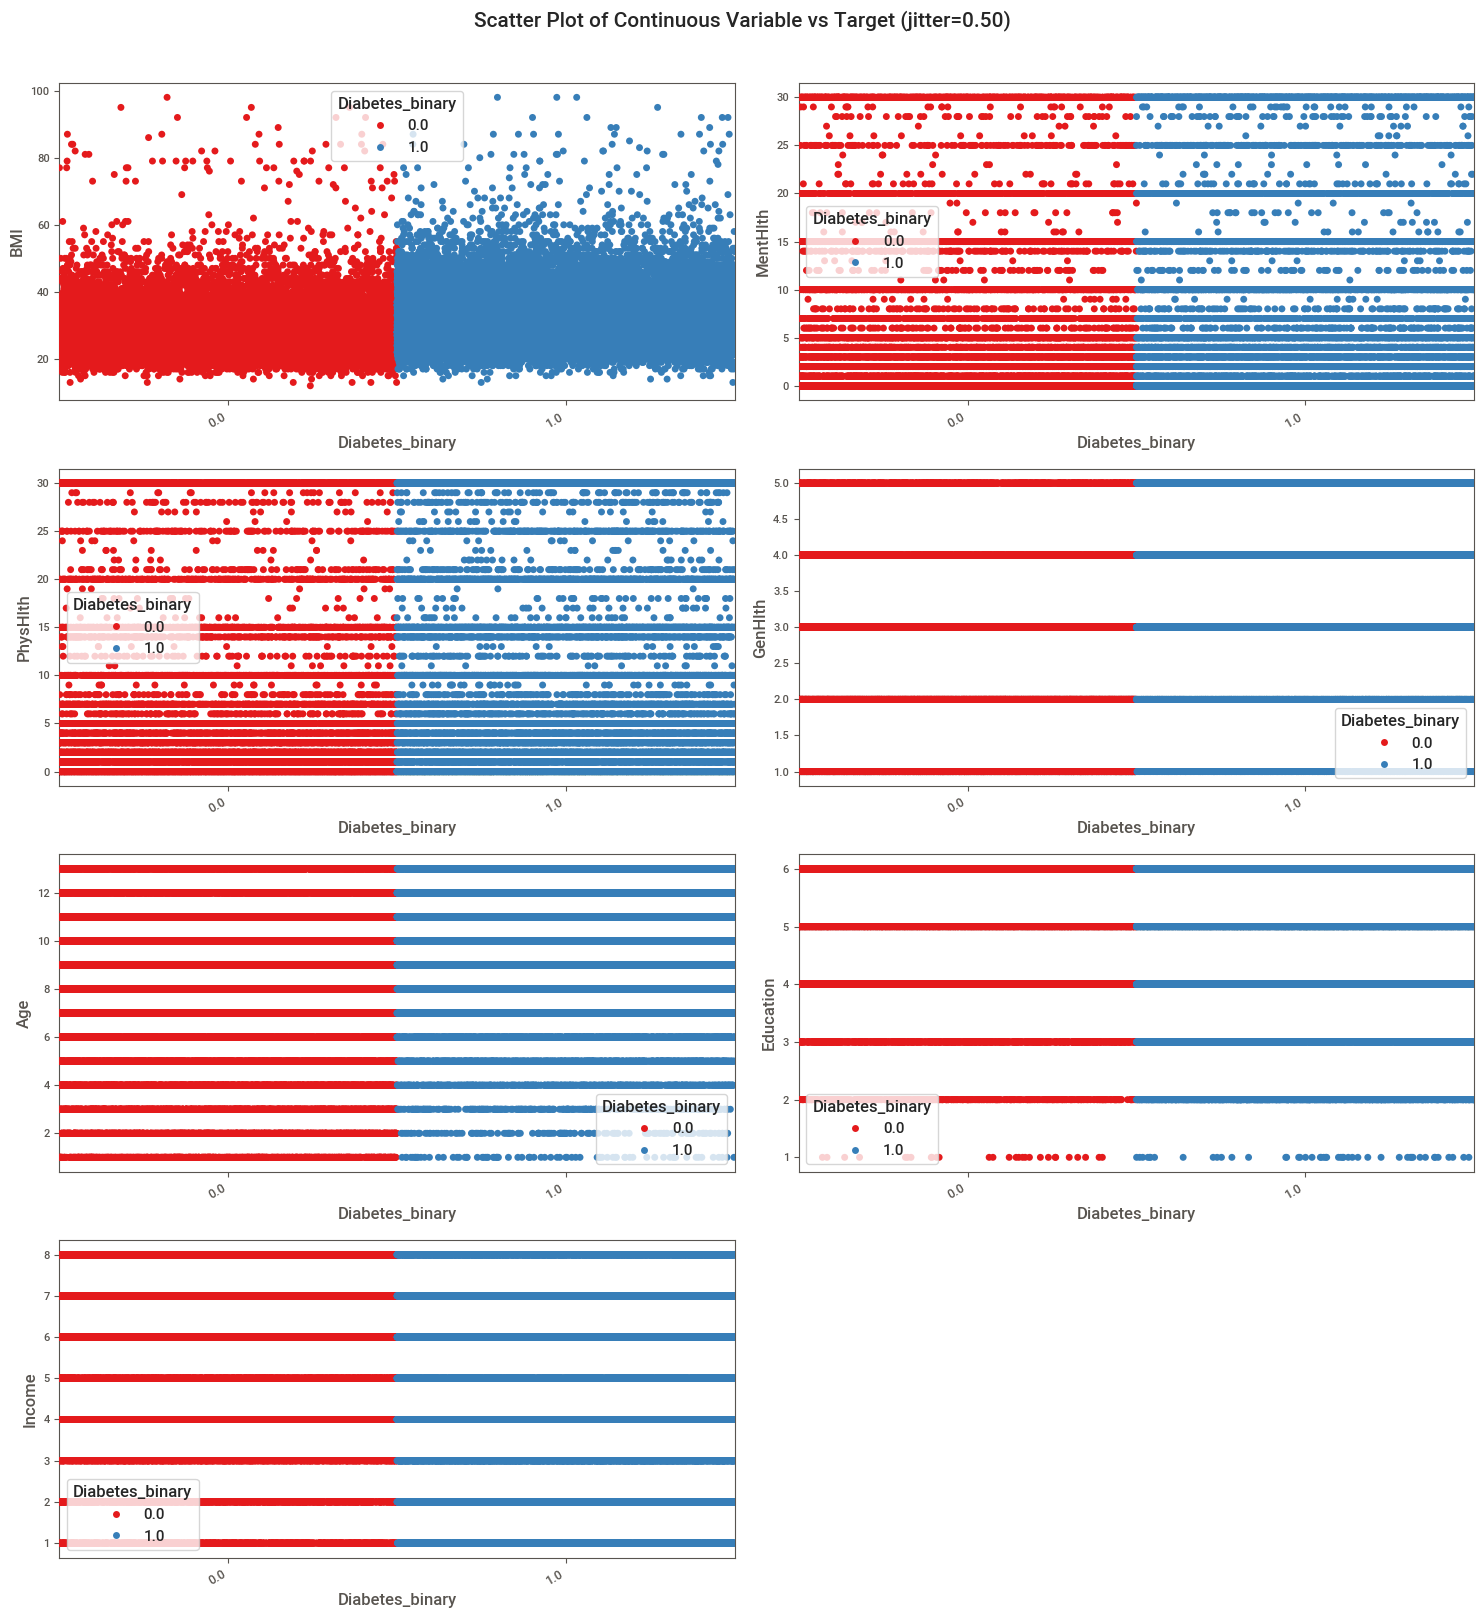

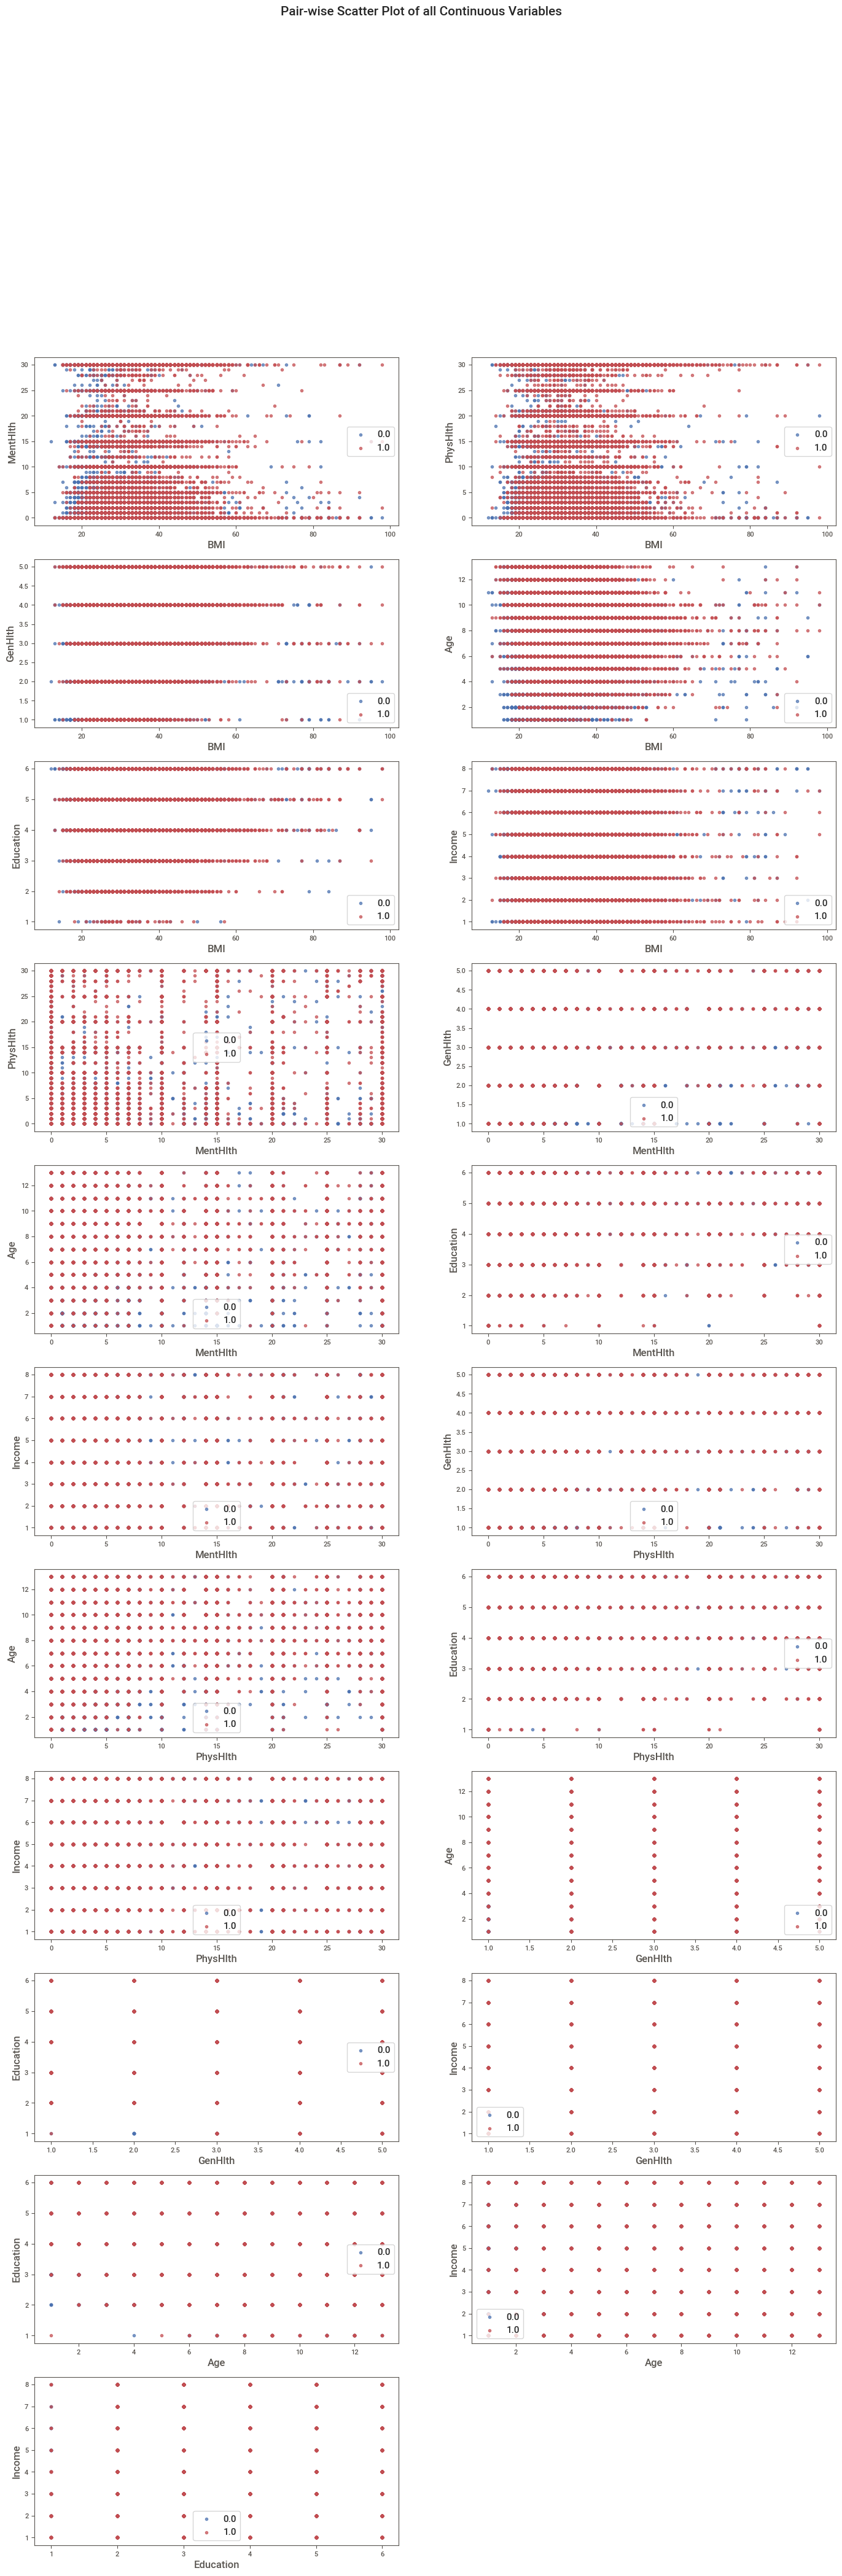

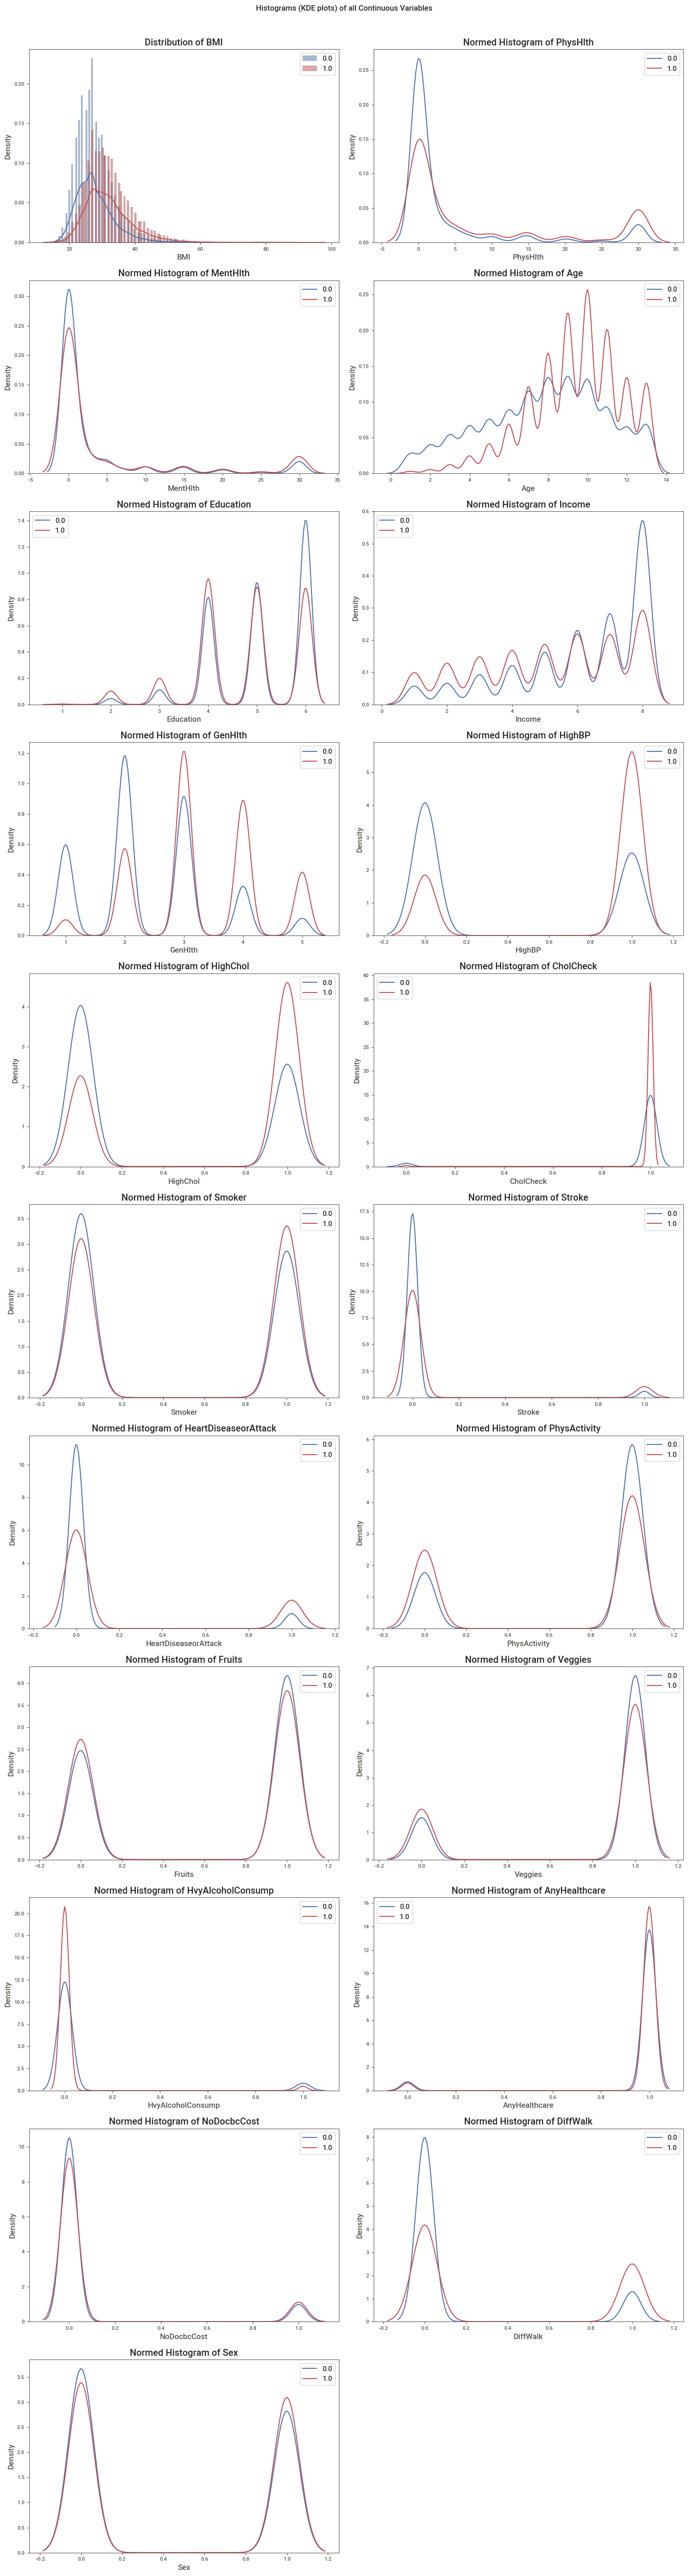

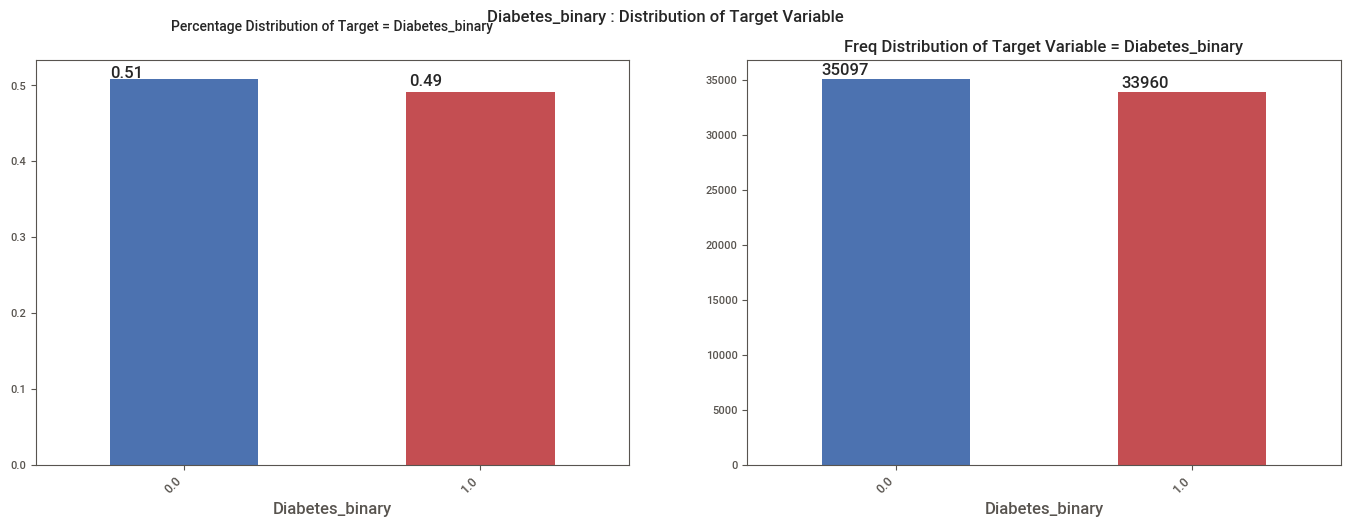

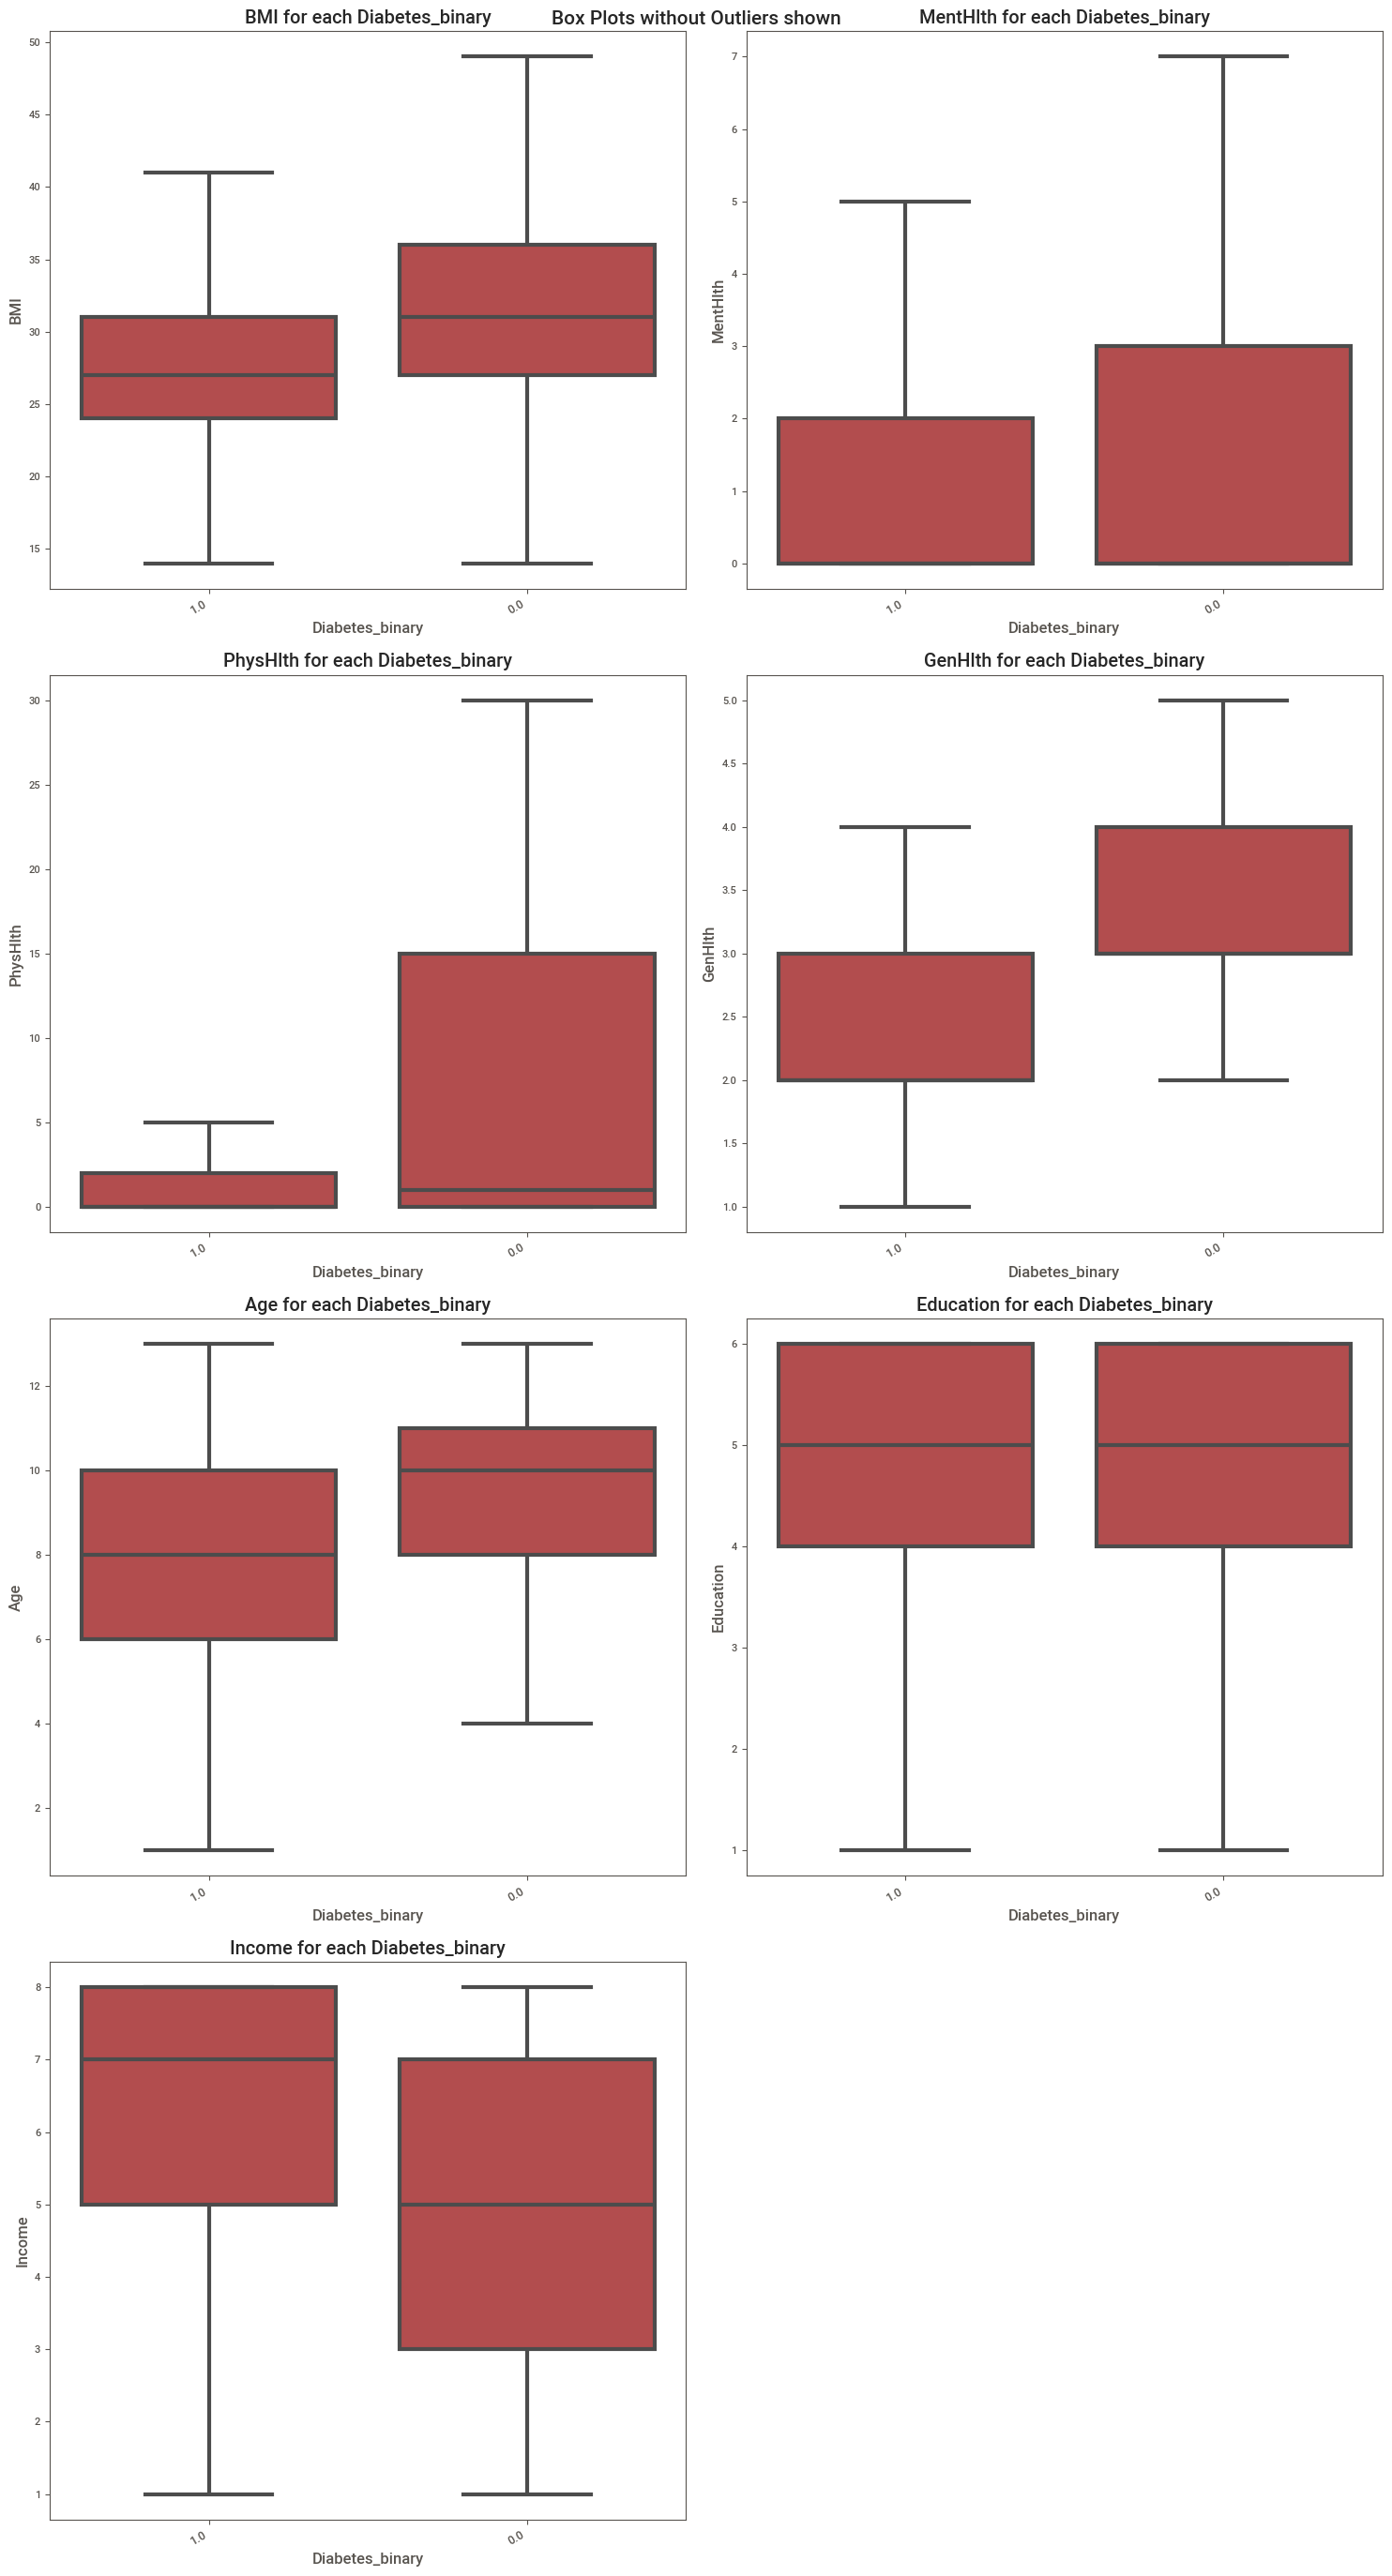

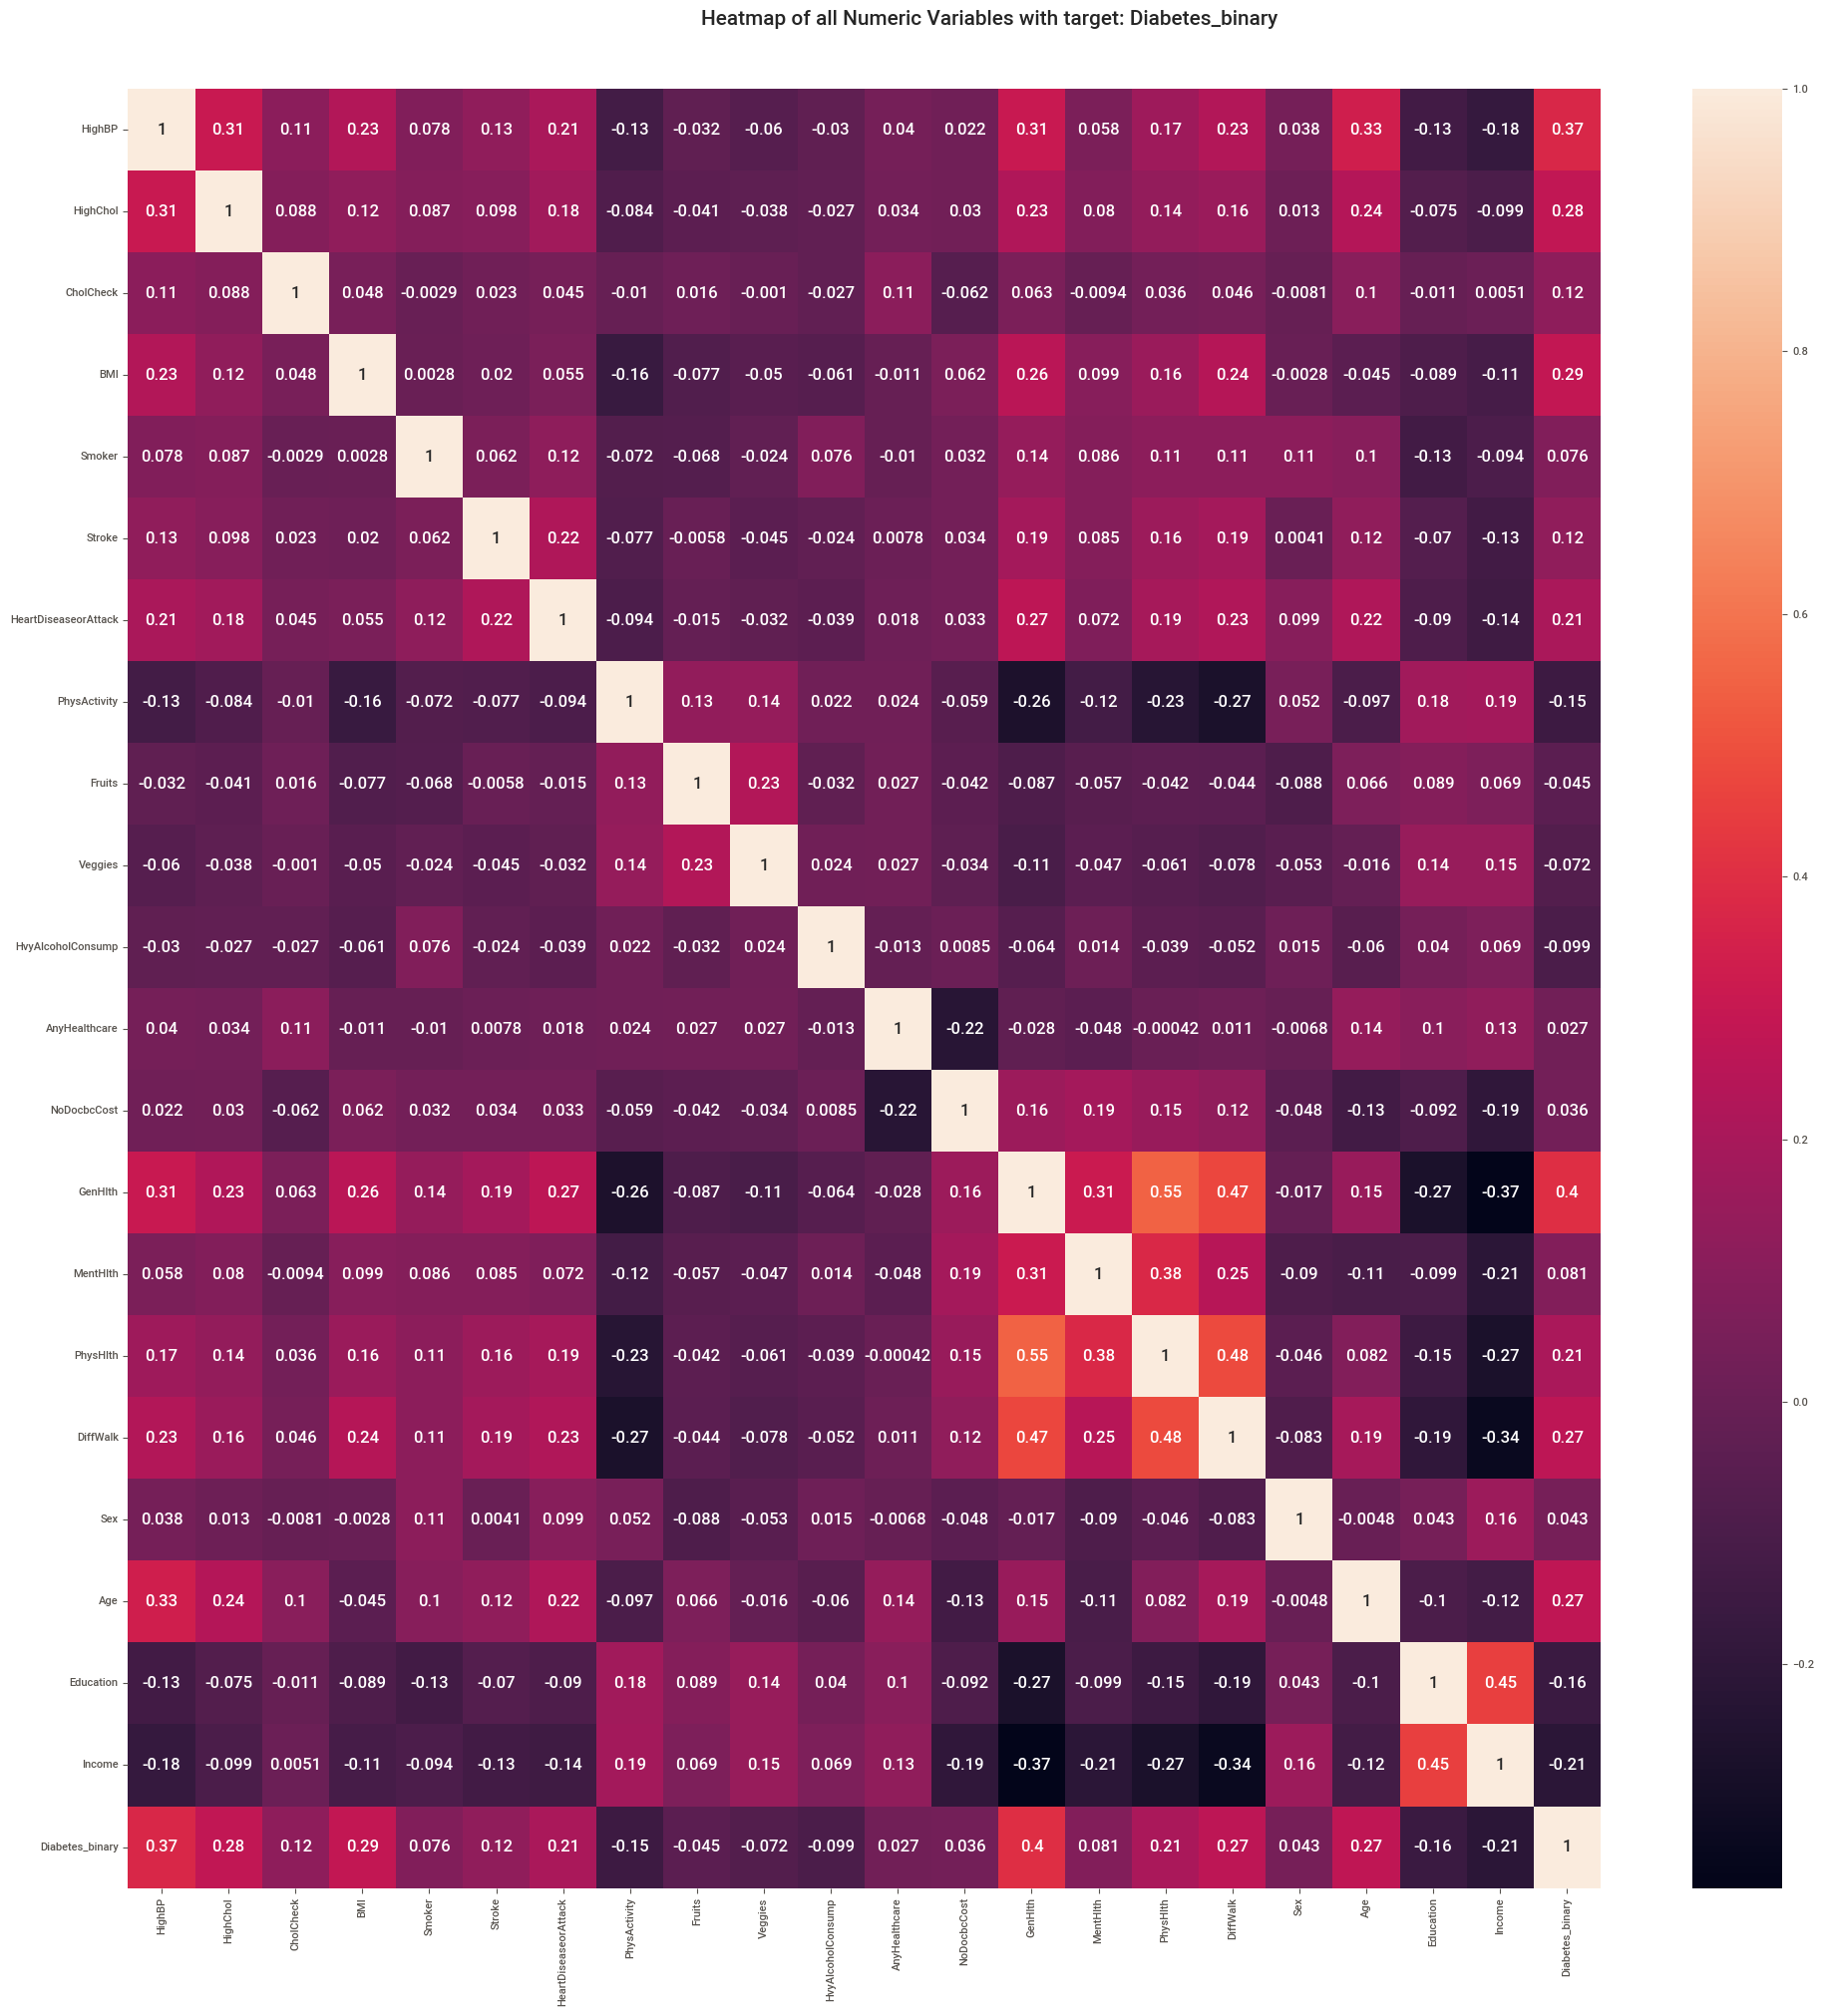

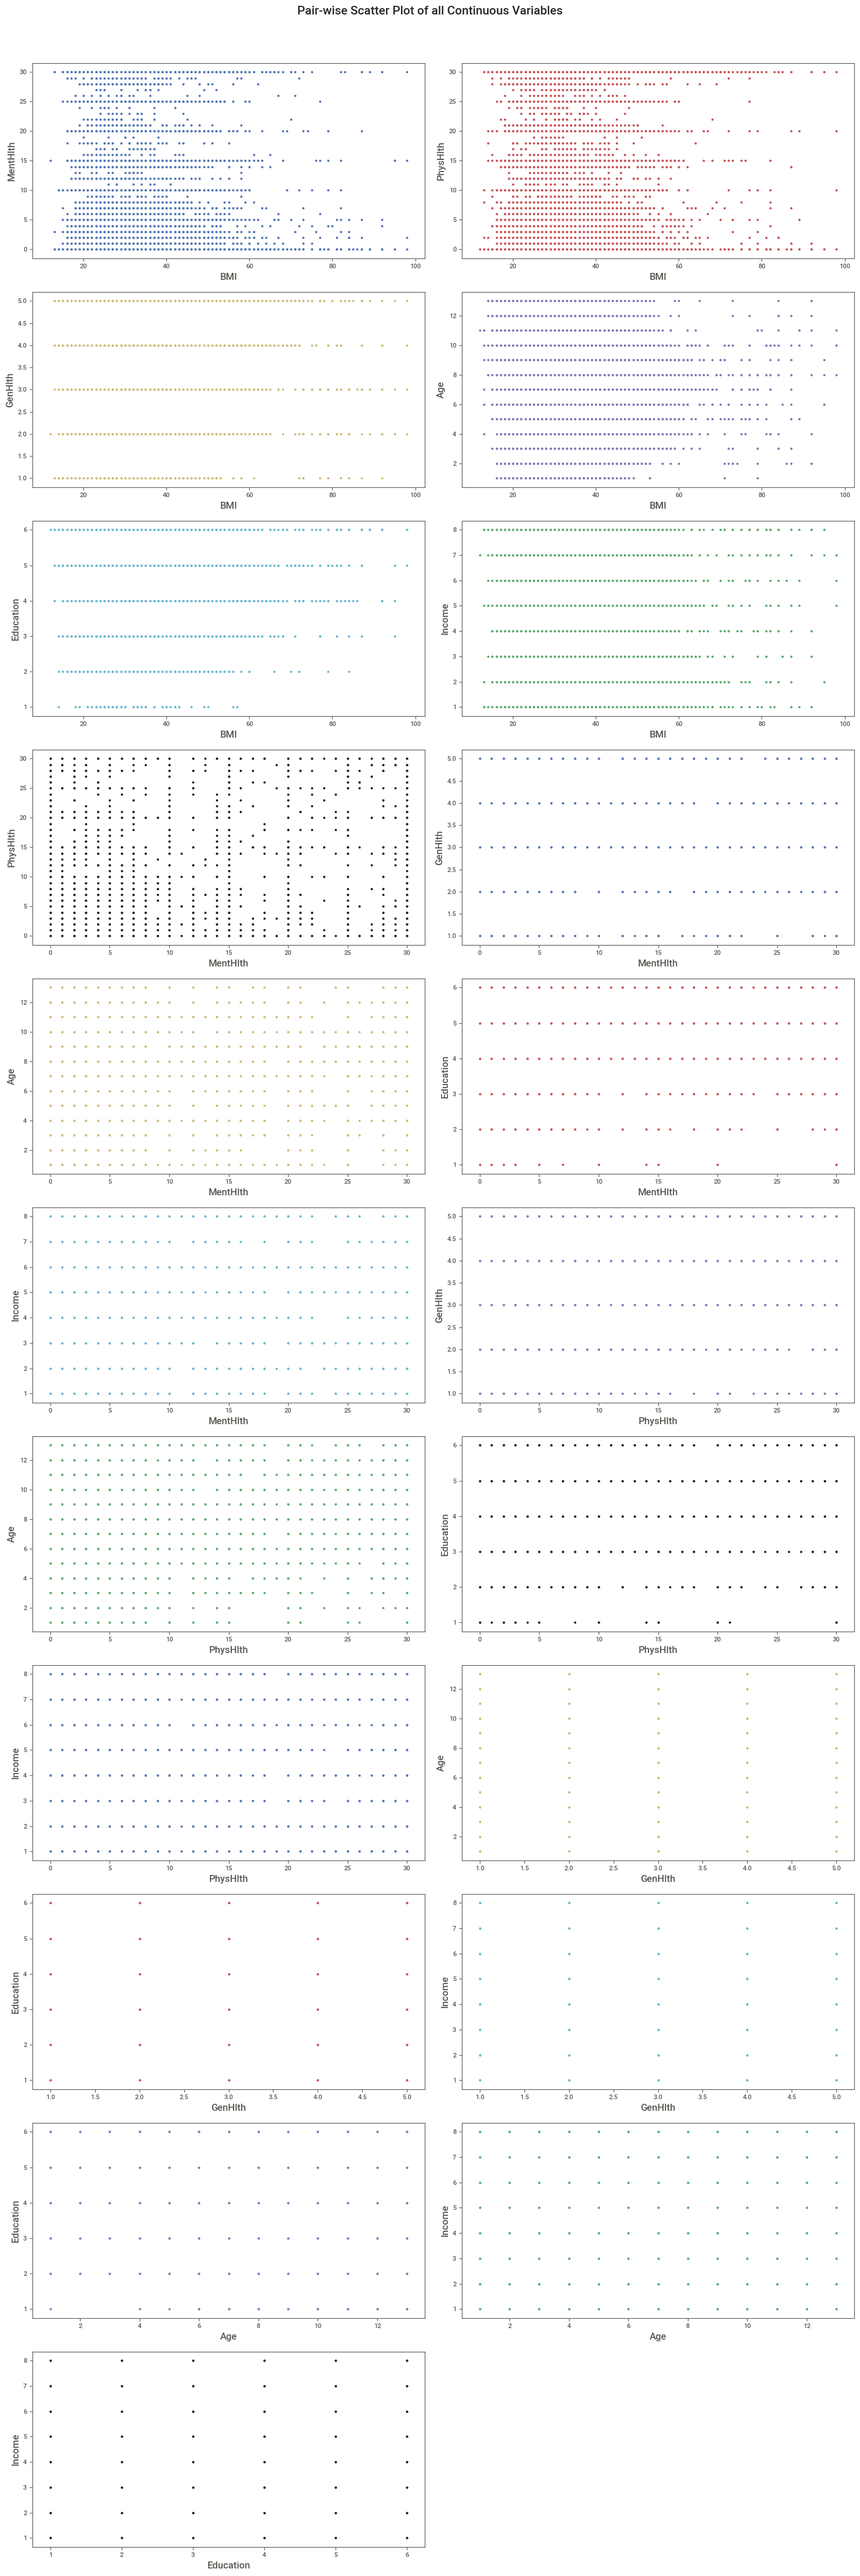

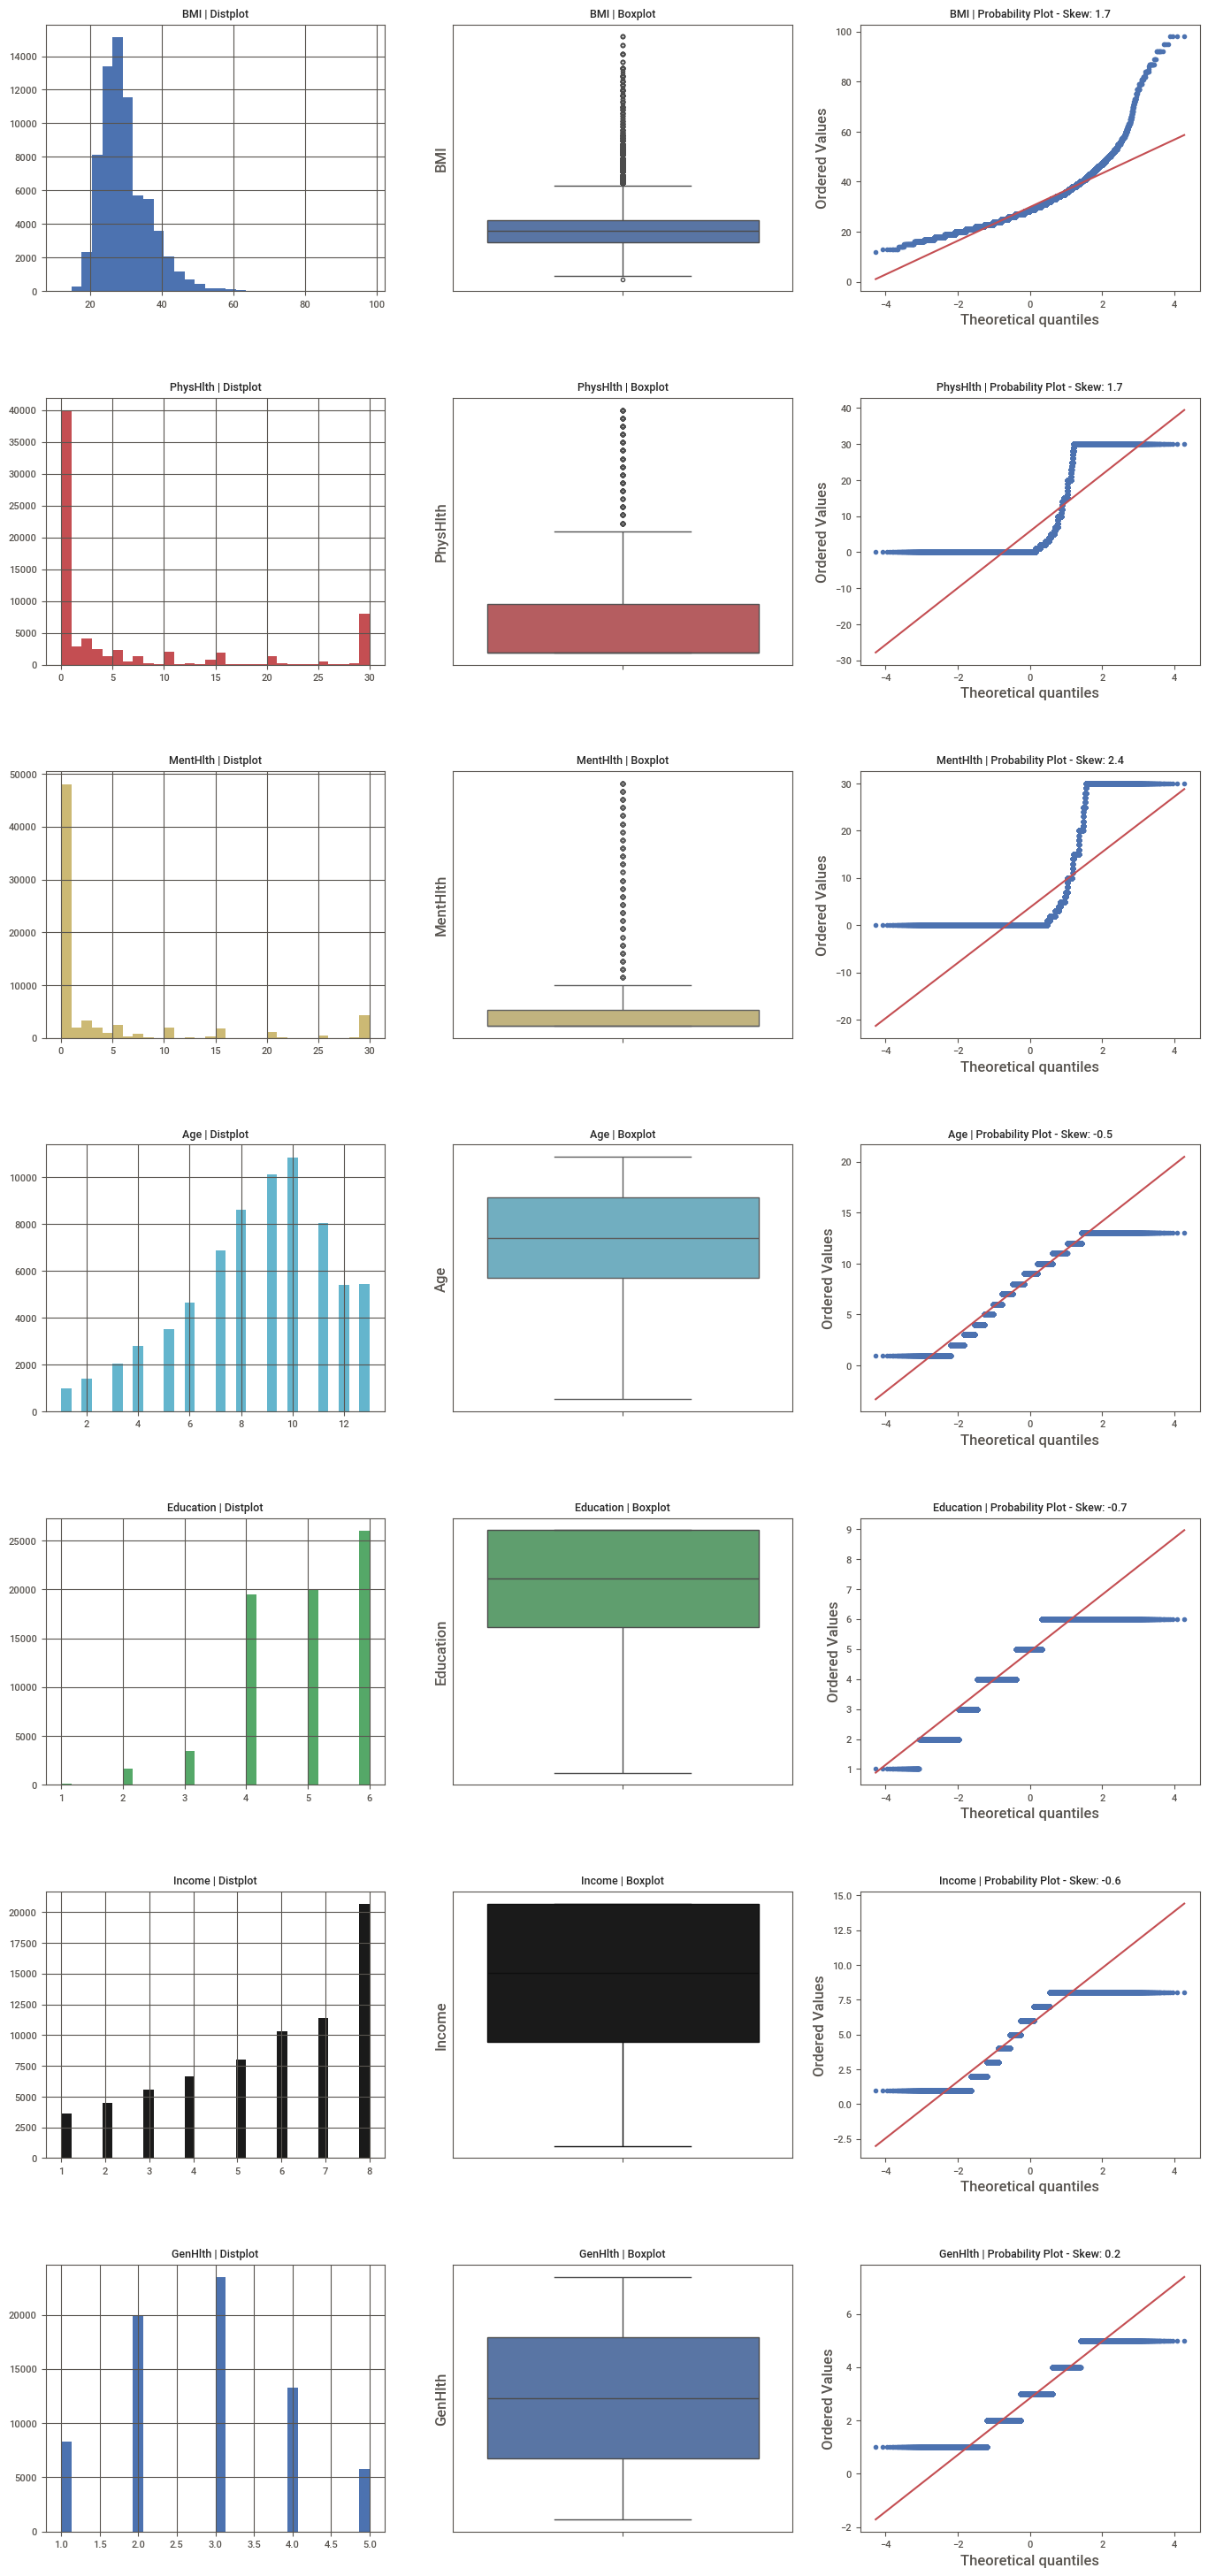

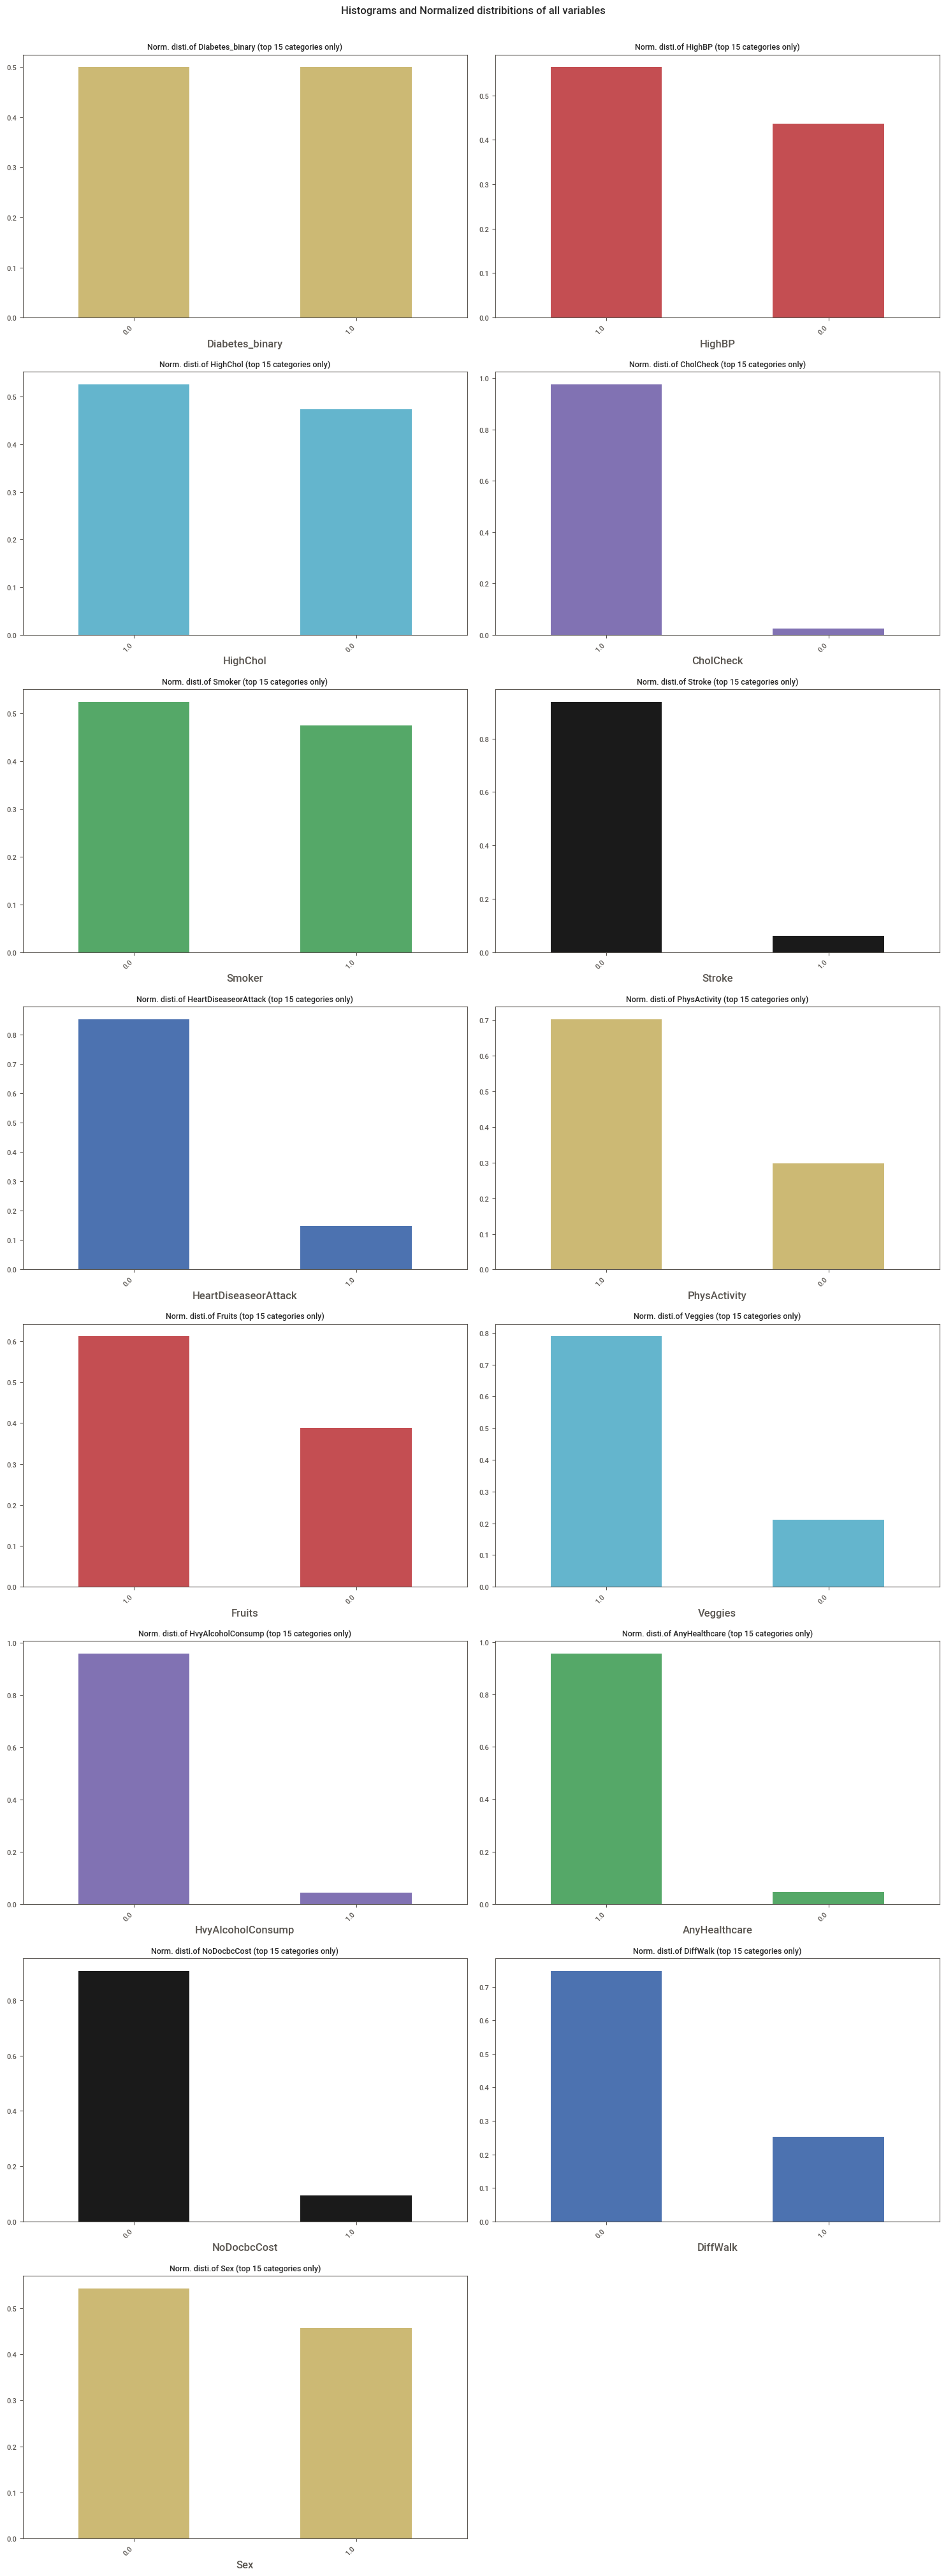

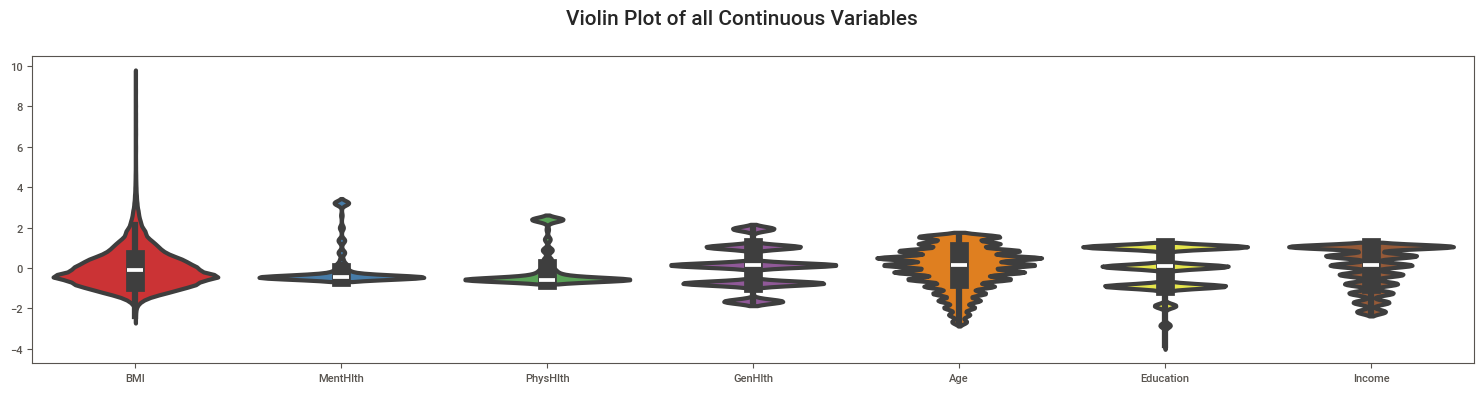

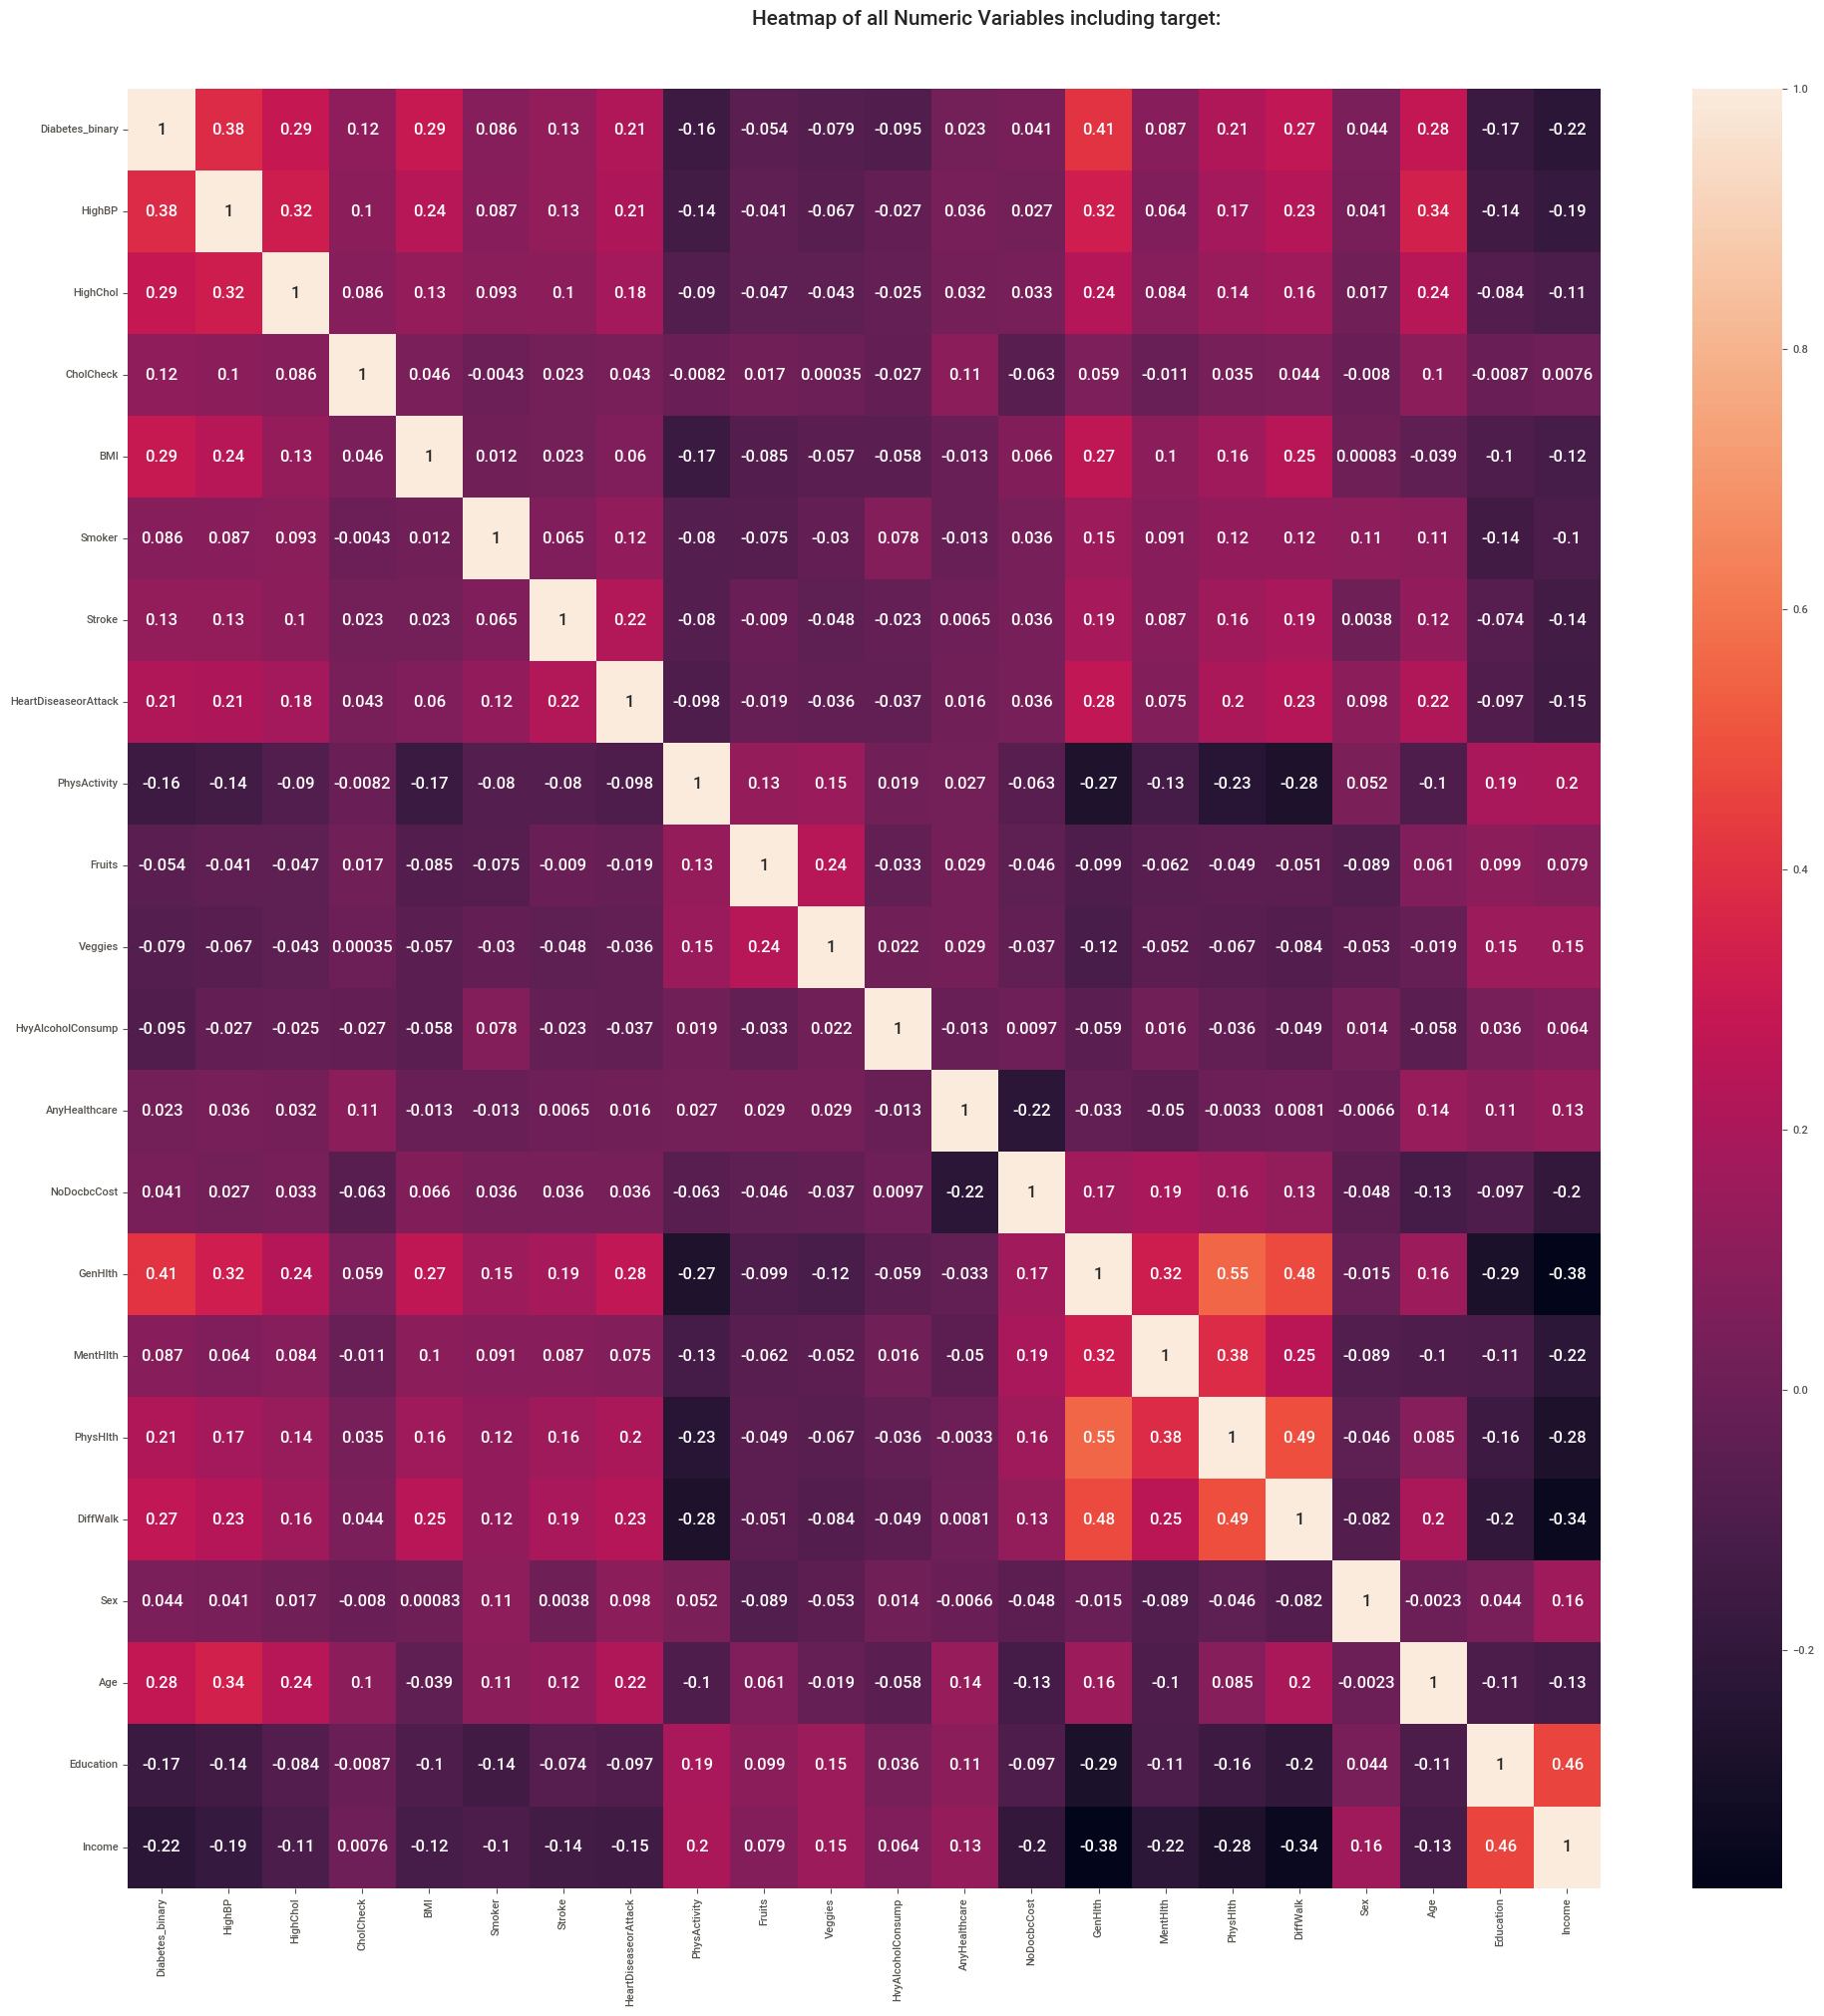

No categorical or numeric vars in data set. Hence no bar charts.
All Plots done
Time to run AutoViz = 64 seconds 

 ###################### AUTO VISUALIZATION Completed ########################


In [6]:
AV = AutoViz_Class()

# Generar un informe de AutoViz
autoviz_report = AV.AutoViz(filename,
                          sep=',',
                          depVar='Diabetes_binary',
                          dfte=df,
                          header=0,
                          verbose=1,
                          chart_format='svg',
                          max_rows_analyzed=150000)

%matplotlib inline
_ = AV.AutoViz(filename)


### Graficas adicionales

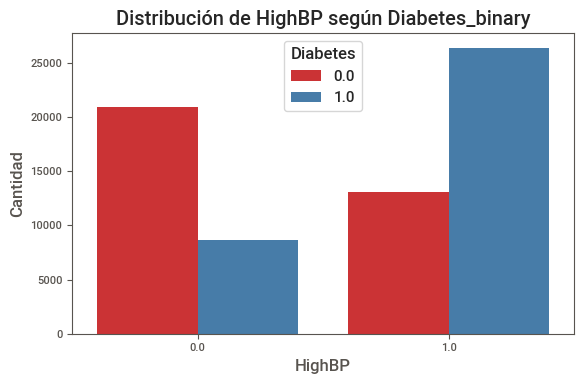

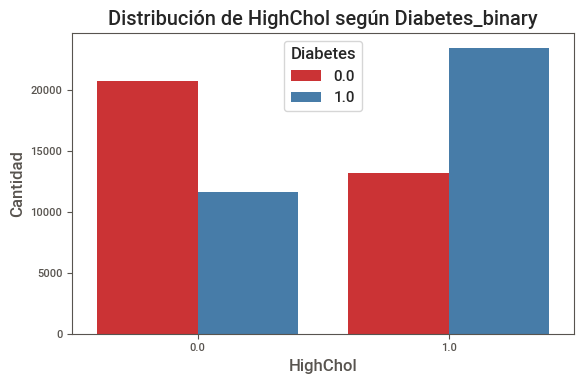

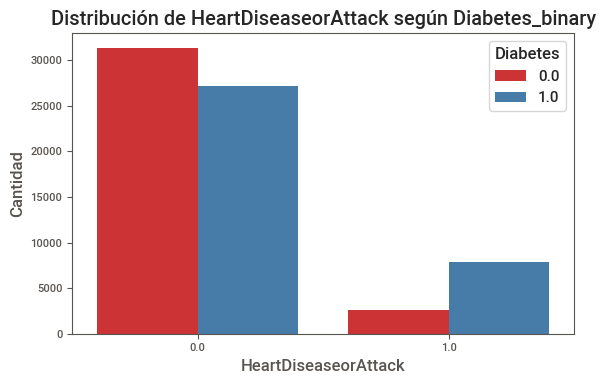

In [7]:
categoricas_binarias = ['HighBP', 'HighChol', 'HeartDiseaseorAttack']

for var in categoricas_binarias:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=var, hue='Diabetes_binary')
    plt.title(f'Distribución de {var} según Diabetes_binary')
    plt.xlabel(var)
    plt.ylabel('Cantidad')
    plt.legend(title='Diabetes')
    plt.tight_layout()
    plt.show()


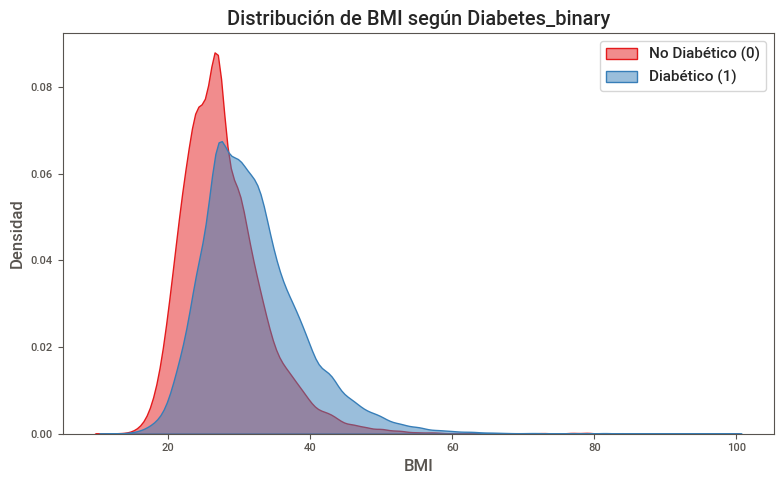

In [8]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df[df['Diabetes_binary'] == 0], x='BMI', fill=True, label='No Diabético (0)', alpha=0.5)
sns.kdeplot(data=df[df['Diabetes_binary'] == 1], x='BMI', fill=True, label='Diabético (1)', alpha=0.5)
plt.title('Distribución de BMI según Diabetes_binary')
plt.xlabel('BMI')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()



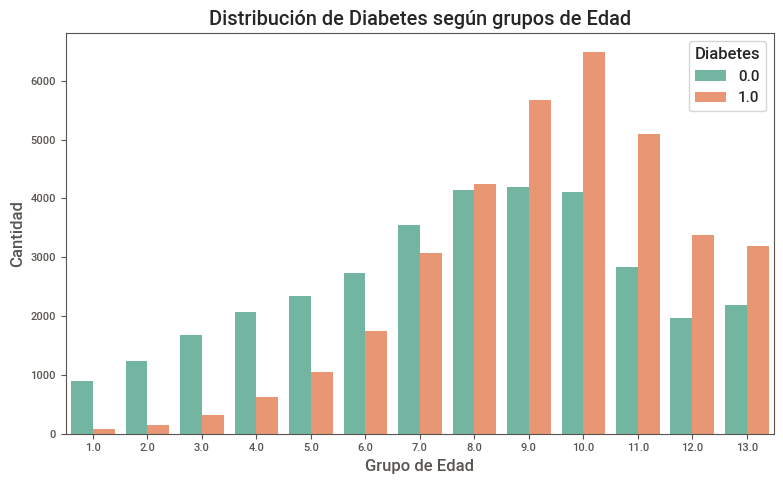

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Age', hue='Diabetes_binary', palette='Set2')
plt.title('Distribución de Diabetes según grupos de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad')
plt.legend(title='Diabetes')
plt.tight_layout()
plt.show()


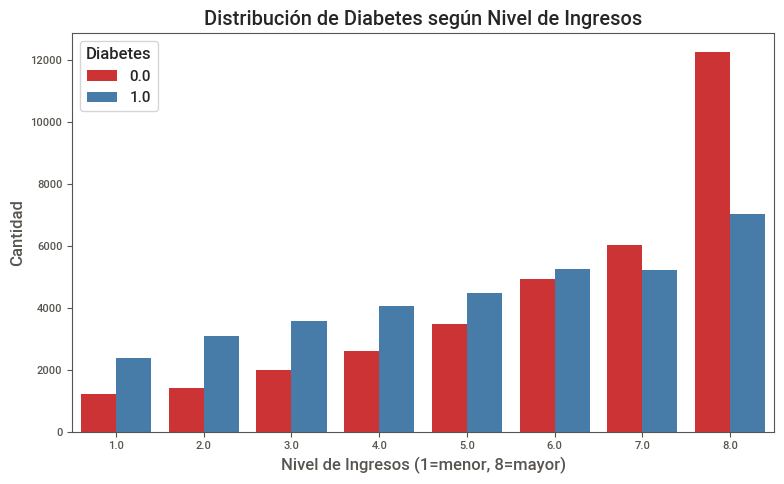

In [10]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Income', hue='Diabetes_binary', palette='Set1')
plt.title('Distribución de Diabetes según Nivel de Ingresos')
plt.xlabel('Nivel de Ingresos (1=menor, 8=mayor)')
plt.ylabel('Cantidad')
plt.legend(title='Diabetes')
plt.tight_layout()
plt.show()


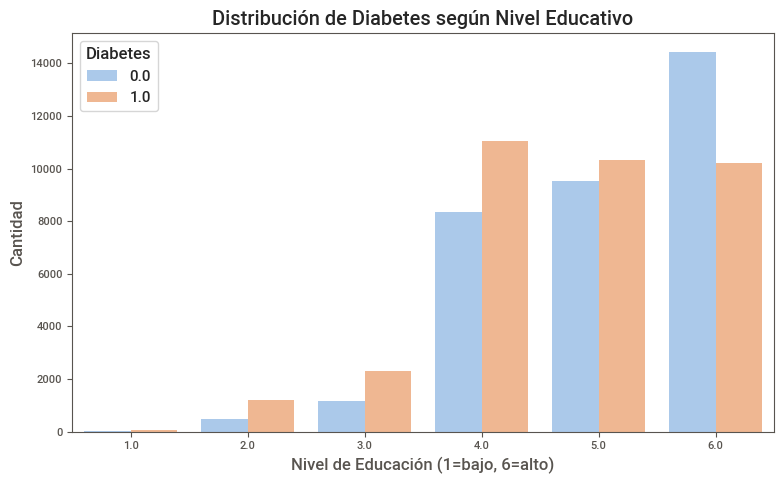

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Education', hue='Diabetes_binary', palette='pastel')
plt.title('Distribución de Diabetes según Nivel Educativo')
plt.xlabel('Nivel de Educación (1=bajo, 6=alto)')
plt.ylabel('Cantidad')
plt.legend(title='Diabetes')
plt.tight_layout()
plt.show()


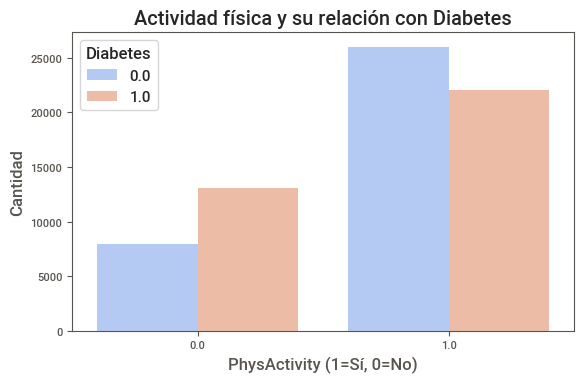

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='PhysActivity', hue='Diabetes_binary', palette='coolwarm')
plt.title('Actividad física y su relación con Diabetes')
plt.xlabel('PhysActivity (1=Sí, 0=No)')
plt.ylabel('Cantidad')
plt.legend(title='Diabetes')
plt.tight_layout()
plt.show()



## Insights y conclusiones del EDA

### Distribución balanceada de la variable objetivo:

    Diabetes_binary tiene proporciones cercanas a 50/50.
    Ideal para entrenar sin necesidad urgente de rebalanceo.

### Variables fuertemente correlacionadas con diabetes (Diabetes_binary = 1)

    HighBP, HighChol, HeartDiseaseorAttack, BMI, GenHlth
    GenHlth (auto percepción de salud) destaca como predictora negativa: cuanto peor la percepción, mayor probabilidad de diabetes.
    BMI tiene una distribución sesgada hacia valores altos en personas con diabetes.

### Variables de comportamiento y autocuidado:

    Personas que se hacen chequeos (CholCheck) tienen menor proporción de diabetes.
    El sedentarismo (PhysActivity=0), el bajo consumo de frutas y verduras (Fruits, Veggies=0), y el alto consumo de alcohol (HvyAlcoholConsump=1) son ligeramente más comunes en pacientes con diabetes.

### Sin valores perdidos o atípicos extremos inaceptables:

    No se detectaron valores nulos.
    El notebook implementa drop_duplicates() y validaciones de isnull().

### Importancia de edad e ingreso:

    Age tiene una distribución que muestra mayor prevalencia de diabetes en personas mayores de 45 años.
    Income muestra ligera correlación inversa: a menor ingreso, mayor incidencia de diabetes.

## Recomendaciones para proxima fase de limpieza y transformaciones

✔ ### Preprocesamiento sugerido:

    Escalar variables continuas (BMI, Age, MentHlth, PhysHlth) usando MinMaxScaler o StandardScaler.
    Codificar variables categóricas binarias como enteros (0,1).
    Dejar ordinales (GenHlth, Education, Income) según su valor o usar codificación ordinal explícita.
    Detectar y mitigar outliers en BMI, MentHlth, PhysHlth si se usan modelos sensibles (e.g. kNN, SVM).

✔ ### Selección de variables:

    Empezar con todas y aplicar técnicas como:

        SelectKBest(chi2)
        RandomForestClassifier.feature_importances_
        RFE con regresión logística